In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

dados_cavaleiros = {
    'id_cavaleiro': [1, 2, 3, 4, 5],
    'cavaleiros': ["Seiya", "Shiryu", "Hyoga", "Shun", "Ikki"],
    'constelacao': ["Pégaso", "Dragão", "Cisne", "Andrômeda", "Fênix"],
    'local_treinamento': ["Santuário (Atenas)", "Cinco Picos de Rozan", "Estremidade Oriental da Sibéria", "Ilha de Andrômeda", "Ilha da Rainha da Morte"],
    'total_episodios': [114, 98, 92, 85, 60],
    'tempo_tela_min': [420.0, 310.0, 280.0, 260.0, None],  # Ikki com NaN para tratamento
    'inimigos_derrotados': [18, 14, 12, 10, 15],
    'maior_classificacao_derrotada': ["General Marina", "General Marina", "Juiz do Inferno", "General Marina", "Juiz do Inferno"]
}

dados_cavaleiros_ouro = {
    'id_ouro': [201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212],
    'nome_cavaleiro': ["Mu", "Aldebaran", "Saga", "Máscara da Morte", "Aiolia", "Shaka", "Dohko", "Milo", "Aiolos", "Shura", "Camus", "Afrodite"],
    'signo': ["Áries", "Touro", "Gêmeos", "Câncer", "Leão", "Virgem", "Libra", "Escorpião", "Sagitário", "Capricórnio", "Aquário", "Peixes"],
    'casa_zodiacal': ["1ª Casa", "2ª Casa", "3ª Casa", "4ª Casa", "5ª Casa", "6ª Casa", "7ª Casa", "8ª Casa", "9ª Casa", "10ª Casa", "11ª Casa", "12ª Casa"],
    'derrotado_por': [None, None, "Casa Vazia", "Shiryu", None, "Ikki", "Casa Vazia", None, "Shura", "Shiryu", "Hyoga", "Shun"] # Os que não foram derrotados/não lutaram contra eles estão como None (NaN)
}

df_cavaleiros_bronze = pd.DataFrame(dados_cavaleiros)
df_cavaleiros_ouro = pd.DataFrame(dados_cavaleiros_ouro)

display(df_cavaleiros_bronze)

display(df_cavaleiros_ouro)

,id_cavaleiro,cavaleiros,constelacao,local_treinamento,total_episodios,tempo_tela_min,inimigos_derrotados,maior_classificacao_derrotada
0,1,Seiya,Pégaso,Santuário (Atenas),114,420.0,18,General Marina
1,2,Shiryu,Dragão,Cinco Picos de Rozan,98,310.0,14,General Marina
2,3,Hyoga,Cisne,Estremidade Oriental da Sibéria,92,280.0,12,Juiz do Inferno
3,4,Shun,Andrômeda,Ilha de Andrômeda,85,260.0,10,General Marina
4,5,Ikki,Fênix,Ilha da Rainha da Morte,60,NaN,15,Juiz do Inferno


,id_ouro,nome_cavaleiro,signo,casa_zodiacal,derrotado_por
0,201,Mu,Áries,1ª Casa,None
1,202,Aldebaran,Touro,2ª Casa,None
2,203,Saga,Gêmeos,3ª Casa,Casa Vazia
3,204,Máscara da Morte,Câncer,4ª Casa,Shiryu
4,205,Aiolia,Leão,5ª Casa,None
5,206,Shaka,Virgem,6ª Casa,Ikki
6,207,Dohko,Libra,7ª Casa,Casa Vazia
7,208,Milo,Escorpião,8ª Casa,None
8,209,Aiolos,Sagitário,9ª Casa,Shura
9,210,Shura,Capricórnio,10ª Casa,Shiryu


In [2]:
df_cavaleiros_bronze['tempo_tela_min'] = df_cavaleiros_bronze['tempo_tela_min'].fillna(185.0)
display(df_cavaleiros_bronze)
df_cavaleiros_ouro['derrotado_por'] = df_cavaleiros_ouro['derrotado_por'].fillna("Deixou o bronze passar.")
display(df_cavaleiros_ouro)

,id_cavaleiro,cavaleiros,constelacao,local_treinamento,total_episodios,tempo_tela_min,inimigos_derrotados,maior_classificacao_derrotada
0,1,Seiya,Pégaso,Santuário (Atenas),114,420.0,18,General Marina
1,2,Shiryu,Dragão,Cinco Picos de Rozan,98,310.0,14,General Marina
2,3,Hyoga,Cisne,Estremidade Oriental da Sibéria,92,280.0,12,Juiz do Inferno
3,4,Shun,Andrômeda,Ilha de Andrômeda,85,260.0,10,General Marina
4,5,Ikki,Fênix,Ilha da Rainha da Morte,60,185.0,15,Juiz do Inferno


,id_ouro,nome_cavaleiro,signo,casa_zodiacal,derrotado_por
0,201,Mu,Áries,1ª Casa,Deixou o bronze passar.
1,202,Aldebaran,Touro,2ª Casa,Deixou o bronze passar.
2,203,Saga,Gêmeos,3ª Casa,Casa Vazia
3,204,Máscara da Morte,Câncer,4ª Casa,Shiryu
4,205,Aiolia,Leão,5ª Casa,Deixou o bronze passar.
5,206,Shaka,Virgem,6ª Casa,Ikki
6,207,Dohko,Libra,7ª Casa,Casa Vazia
7,208,Milo,Escorpião,8ª Casa,Deixou o bronze passar.
8,209,Aiolos,Sagitário,9ª Casa,Shura
9,210,Shura,Capricórnio,10ª Casa,Shiryu


In [3]:
bronze_melt = pd.melt(
    df_cavaleiros_bronze,
    id_vars=['id_cavaleiro','cavaleiros','constelacao','local_treinamento','inimigos_derrotados','total_episodios'],
    value_vars=['tempo_tela_min'],
    var_name='Vezes em que apareceu',
    value_name="Tempo de Tela"
).drop(columns=['Vezes em que apareceu'])
bronze_melt

,id_cavaleiro,cavaleiros,constelacao,local_treinamento,inimigos_derrotados,total_episodios,Tempo de Tela
0,1,Seiya,Pégaso,Santuário (Atenas),18,114,420.0
1,2,Shiryu,Dragão,Cinco Picos de Rozan,14,98,310.0
2,3,Hyoga,Cisne,Estremidade Oriental da Sibéria,12,92,280.0
3,4,Shun,Andrômeda,Ilha de Andrômeda,10,85,260.0
4,5,Ikki,Fênix,Ilha da Rainha da Morte,15,60,185.0


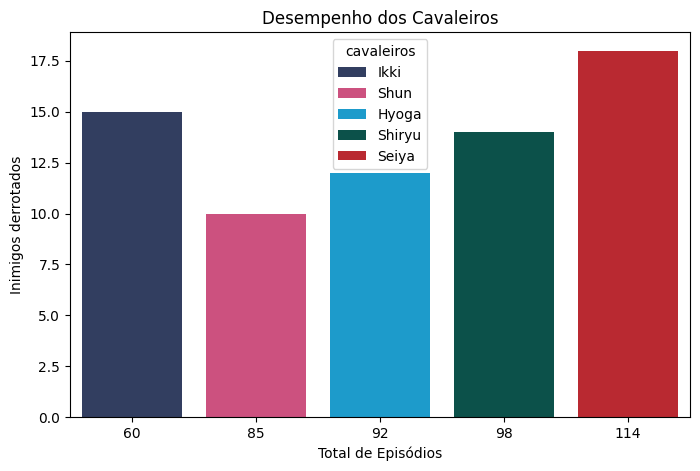

In [4]:
cores_cavaleiros = {
    'Seiya': '#D1111C',   # Prateado (Armadura de Pégaso v1)
    'Shiryu': '#005C53',  # Verde Esmeralda (Armadura de Dragão)
    'Hyoga': '#00A8E8',   # Azul Gelo / Cisne
    'Shun': '#E03C7A',    # Vermelho/Rosa Metalizado (Armadura de Andrômeda)
    'Ikki': '#2B3A67'     # Azul Escuro com Laranja/Fênix
}

plt.figure(figsize=(8,5))

sns.barplot(data=bronze_melt,
            x='total_episodios',
            y='inimigos_derrotados',
            hue='cavaleiros',
            palette=cores_cavaleiros,
            errorbar=None)

plt.title("Desempenho dos Cavaleiros")
plt.xlabel("Total de Episódios")
plt.ylabel("Inimigos derrotados")

plt.show()

In [6]:
df_cavaleiros_ouro['derrotado_por'] = df_cavaleiros_ouro['derrotado_por'].astype(str).str.split(', ')
df_cavaleiros_ouro = df_cavaleiros_ouro.explode('derrotado_por')

df_bronze_ouro = pd.merge(
    bronze_melt,
    df_cavaleiros_ouro,
    left_on='cavaleiros',
    right_on='derrotado_por',
    how='inner'
)

df_bronze_ouro

,id_cavaleiro,cavaleiros,constelacao,local_treinamento,inimigos_derrotados,total_episodios,Tempo de Tela,id_ouro,nome_cavaleiro,signo,casa_zodiacal,derrotado_por
0,2,Shiryu,Dragão,Cinco Picos de Rozan,14,98,310.0,204,Máscara da Morte,Câncer,4ª Casa,Shiryu
1,2,Shiryu,Dragão,Cinco Picos de Rozan,14,98,310.0,210,Shura,Capricórnio,10ª Casa,Shiryu
2,3,Hyoga,Cisne,Estremidade Oriental da Sibéria,12,92,280.0,211,Camus,Aquário,11ª Casa,Hyoga
3,4,Shun,Andrômeda,Ilha de Andrômeda,10,85,260.0,212,Afrodite,Peixes,12ª Casa,Shun
4,5,Ikki,Fênix,Ilha da Rainha da Morte,15,60,185.0,206,Shaka,Virgem,6ª Casa,Ikki


C:\Users\Amanda Nazaré\AppData\Local\Temp\ipykernel_20340\2285149785.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_bronze_ouro,x='cavaleiros', palette=cores_cavaleiros)


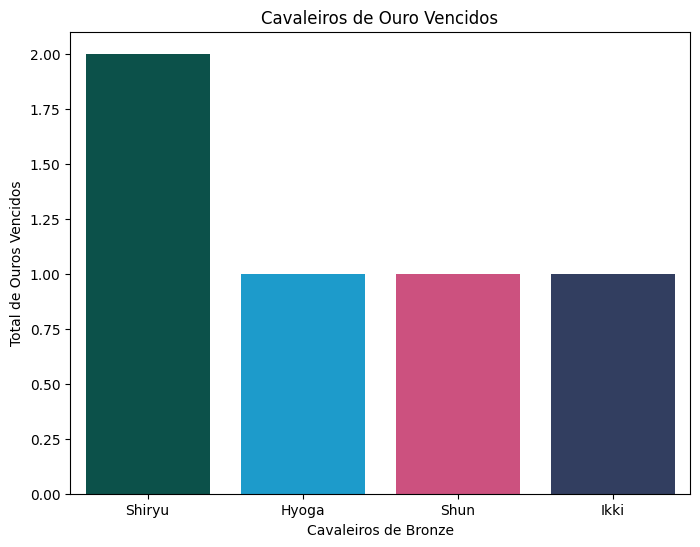

In [12]:
cores_cavaleiros = {
    'Seiya': '#D1111C',   # Prateado (Armadura de Pégaso v1)
    'Shiryu': '#005C53',  # Verde Esmeralda (Armadura de Dragão)
    'Hyoga': '#00A8E8',   # Azul Gelo / Cisne
    'Shun': '#E03C7A',    # Vermelho/Rosa Metalizado (Armadura de Andrômeda)
    'Ikki': '#2B3A67'     # Azul Escuro com Laranja/Fênix
}

plt.figure(figsize=(8,6))
sns.countplot(data=df_bronze_ouro,x='cavaleiros', palette=cores_cavaleiros)

plt.title("Cavaleiros de Ouro Vencidos")
plt.ylabel("Total de Ouros Vencidos")
plt.xlabel("Cavaleiros de Bronze")

plt.show()

In [17]:
df_cruzamento = pd.crosstab(df_bronze_ouro['constelacao'],df_bronze_ouro['signo'])
df_cruzamento

signo,Aquário,Capricórnio,Câncer,Peixes,Virgem
constelacao,,,,,
Andrômeda,0,0,0,1,0
Cisne,1,0,0,0,0
Dragão,0,1,1,0,0
Fênix,0,0,0,0,1


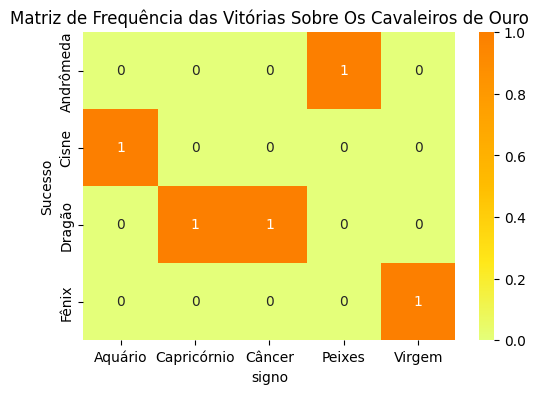

In [18]:
plt.figure(figsize=(6,4))

sns.heatmap(df_cruzamento,
            annot=True,
            fmt='d',
            cmap='Wistia',
            cbar=True)

plt.title('Matriz de Frequência das Vitórias Sobre Os Cavaleiros de Ouro')
plt.ylabel('Sucesso')

plt.show()